In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [3]:
train_df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

In [4]:
print("train" , train_df.shape)
print("test", test_df.shape)

train (891, 12)
test (418, 11)


In [5]:
print("train\n", train_df.dtypes)
print("\ntest\n", test_df.dtypes)

train
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

test
 PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [6]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
print("train\n", train_df.isnull().sum())
print("\ntest\n", test_df.isnull().sum())

train
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

test
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [8]:
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())

In [9]:
print("Liman Dağılımı:")
print(train_df['Embarked'].value_counts())

embarked_mode = train_df['Embarked'].mode()[0]
print(f"\nEn çok tekrar eden liman (Mode): {embarked_mode}")

Liman Dağılımı:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

En çok tekrar eden liman (Mode): S


In [10]:
train_df['Embarked'] = train_df['Embarked'].fillna(embarked_mode)

In [11]:
# Kadın: 1, Erkek: 0
train_df['Sex'] = train_df['Sex'].map({'female': 1, 'male': 0})
test_df['Sex'] = test_df['Sex'].map({'female': 1, 'male': 0})

In [12]:
train_df = pd.get_dummies(train_df, columns=['Embarked'])
test_df = pd.get_dummies(test_df, columns=['Embarked'])

In [13]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,False,False,True


In [14]:
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked_C", "Embarked_Q", "Embarked_S"]

X = train_df[features]
y = train_df["Survived"]

X_test = test_df[features]

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,3,0,22.0,1,0,7.2500,False,False,True
1,1,1,38.0,1,0,71.2833,True,False,False
2,3,1,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,3,0,35.0,0,0,8.0500,False,False,True


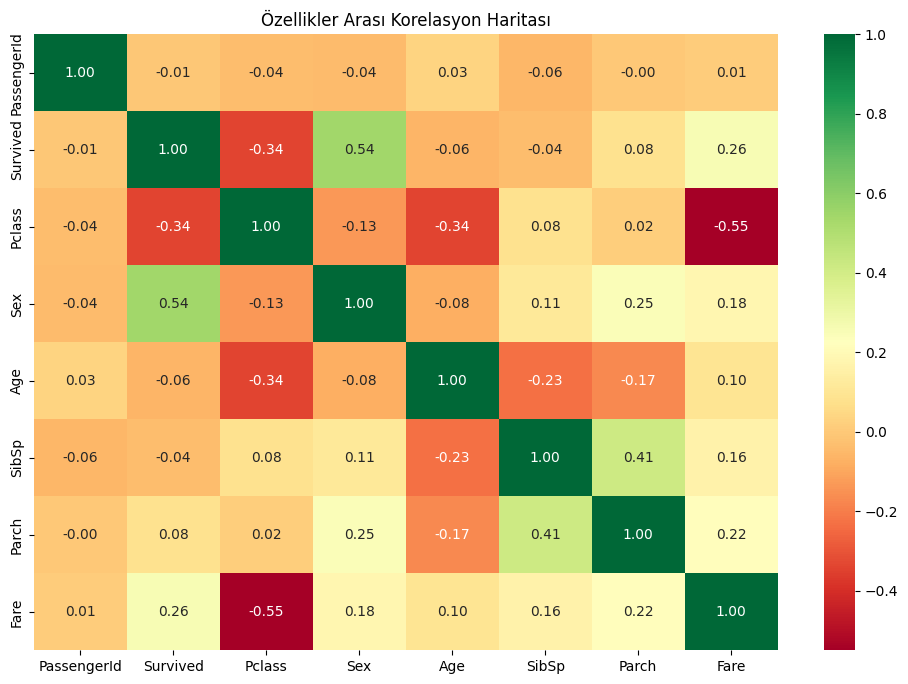

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = train_df.select_dtypes(include=['int64', 'float64', 'int32', 'uint8'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Özellikler Arası Korelasyon Haritası')
plt.show()

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scale_cols = ['Age', 'Fare']
train_df[scale_cols] = scaler.fit_transform(train_df[scale_cols])
test_df[scale_cols] = scaler.transform(test_df[scale_cols])

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

final_features = ["Pclass", "Sex", "Fare", "Embarked_C", "Embarked_Q", "Embarked_S"]

X = train_df[final_features]
y = train_df["Survived"]

model = RandomForestClassifier(n_estimators=250, max_depth=6, min_samples_leaf=3, random_state=42)

cv_scores = cross_val_score(model, X, y, cv=5)

print(f"Cross-Validation Skorları: {cv_scores}")
print(f"Ortalama Başarı: %{cv_scores.mean()*100:.2f}")

Cross-Validation Skorları: [0.7877095  0.78651685 0.84831461 0.80337079 0.80337079]
Ortalama Başarı: %80.59


In [18]:
model.fit(X, y)

X_test = test_df[final_features]

predictions = model.predict(X_test)

output = pd.DataFrame({'PassengerId': test_df.PassengerId, 'Survived': predictions})
output.to_csv('submission.csv', index=False)